In [177]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file

import tqdm
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("Agg")
# matplolib inline 
%matplotlib inline
import numpy as np

# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [178]:
# import gdown
# url = 'https://drive.google.com/drive/folders/16UthOas97BntH8ngVSofxgd2JrxSLDZU'
# gdown.download_folder(url)

# Hyperparams Constants

In [179]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()

In [180]:
epochs = 1000
representiation_dim = 64
EXPERIMENT_NAME='100 world 1000 path overfit offset-encoding end2end encoder trianing'

In [181]:

CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'dim_mults':(1, 2, 4, 8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    'attention':False, 
    
    # transfomer model config
    'num_heads': 4,
    'num_layers': 4,
    'use_sin_activation': True,
    
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim//2,
    
    # Hyperparameters for training
    'batch_size': 8,
    'num_epochs': epochs,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },
    
    'loss_weights':{
        'MSE': 0.3,
        'ObstacleFreePathLoss': 0.5,
        'GraphBasedConsistencyLoss':0.2,
    },
    # Hyperparameters for diffusion process
    'noise_steps': 256,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 1000,
    'n_worlds': 100,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
    'single_world_dataset':False,
}

# Dataloader

In [182]:
from dataset import RobotPathDataset

In [183]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

### Normalizer

In [184]:
file = '/home/karim.samir.lotfy/tum-adlr-ss24-09/data/RobotPathData/SingleSphere02_all.db'
# file = '/home/karim.samir.lotfy/tum-adlr-ss24-09/data/SingleSphere02_one-world.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'], single_world_dataset=CONFIG['single_world_dataset'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

data shape: torch.Size([11000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:18, samples: 11000
 sample shape torch.Size([64, 2]) with 11000 samples


In [185]:
np.unique(dataset.worlds_indx)

array([167, 168, 229, 230, 300, 354, 355, 362, 363, 466, 634, 635, 654,
       655, 893, 894, 987, 988])

In [186]:
denormalized_sample = normalizer.denormalize(sample['path'])
denormalized_sample

tensor([[8.6140, 0.3061],
        [8.4874, 0.3569],
        [8.3608, 0.4078],
        [8.2342, 0.4586],
        [8.1064, 0.5068],
        [7.9785, 0.5546],
        [7.8506, 0.6024],
        [7.7244, 0.6550],
        [7.5987, 0.7091],
        [7.4731, 0.7632],
        [7.3453, 0.8109],
        [7.2165, 0.8556],
        [7.0876, 0.9003],
        [6.9613, 0.9512],
        [6.8375, 1.0083],
        [6.7136, 1.0654],
        [6.5853, 1.1087],
        [6.4514, 1.1349],
        [6.3176, 1.1612],
        [6.1837, 1.1874],
        [6.0480, 1.1802],
        [5.9121, 1.1679],
        [5.7762, 1.1557],
        [5.6402, 1.1437],
        [5.5036, 1.1374],
        [5.3670, 1.1311],
        [5.2304, 1.1248],
        [5.0940, 1.1177],
        [4.9577, 1.1093],
        [4.8215, 1.1010],
        [4.6853, 1.0927],
        [4.5490, 1.0829],
        [4.4127, 1.0725],
        [4.2764, 1.0621],
        [4.1402, 1.0517],
        [4.0036, 1.0476],
        [3.8670, 1.0435],
        [3.7304, 1.0393],
        [3.5

In [187]:
WORLD_IMG = sample['world_img'] 

In [188]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


In [189]:
sample_batch['world_indx'].shape

torch.Size([8])

## Loss Functions

### MSE

### ObstacleFreeLoss

In [190]:
from model import ObstacleFreePathLoss, GraphBasedConsistencyLoss
obstacle_avoidance_loss_fn = ObstacleFreePathLoss(normalizer=CONFIG['normalizer'])
graph_based_consistency_loss_fn = GraphBasedConsistencyLoss()

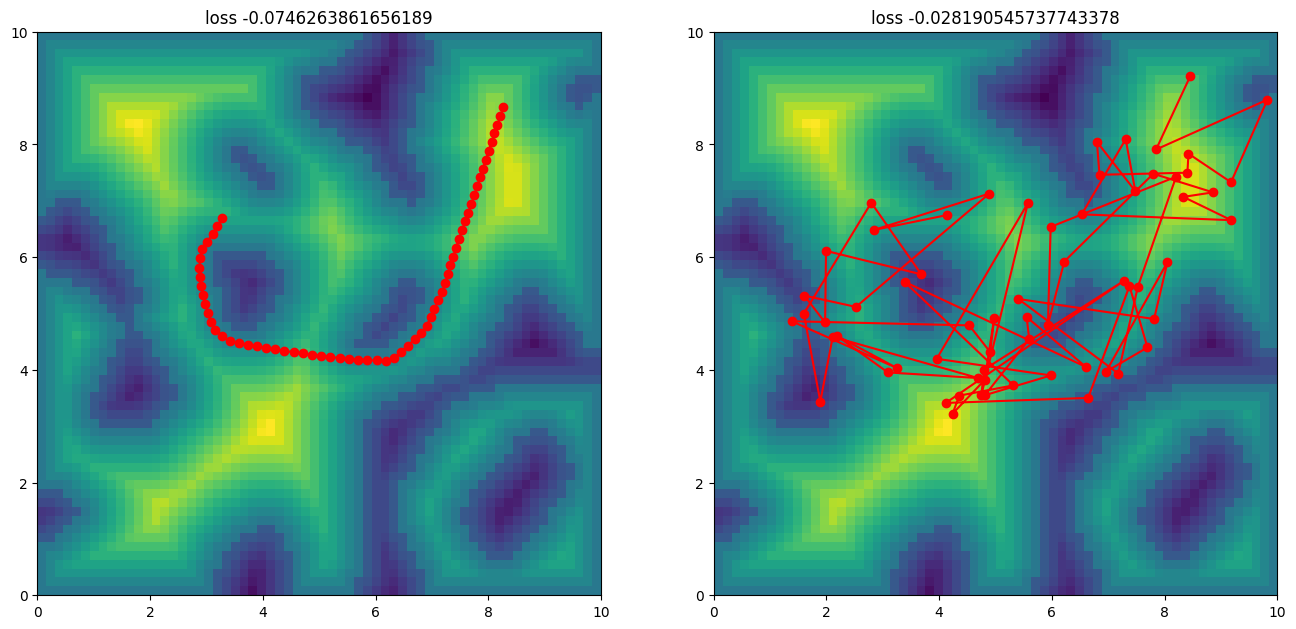

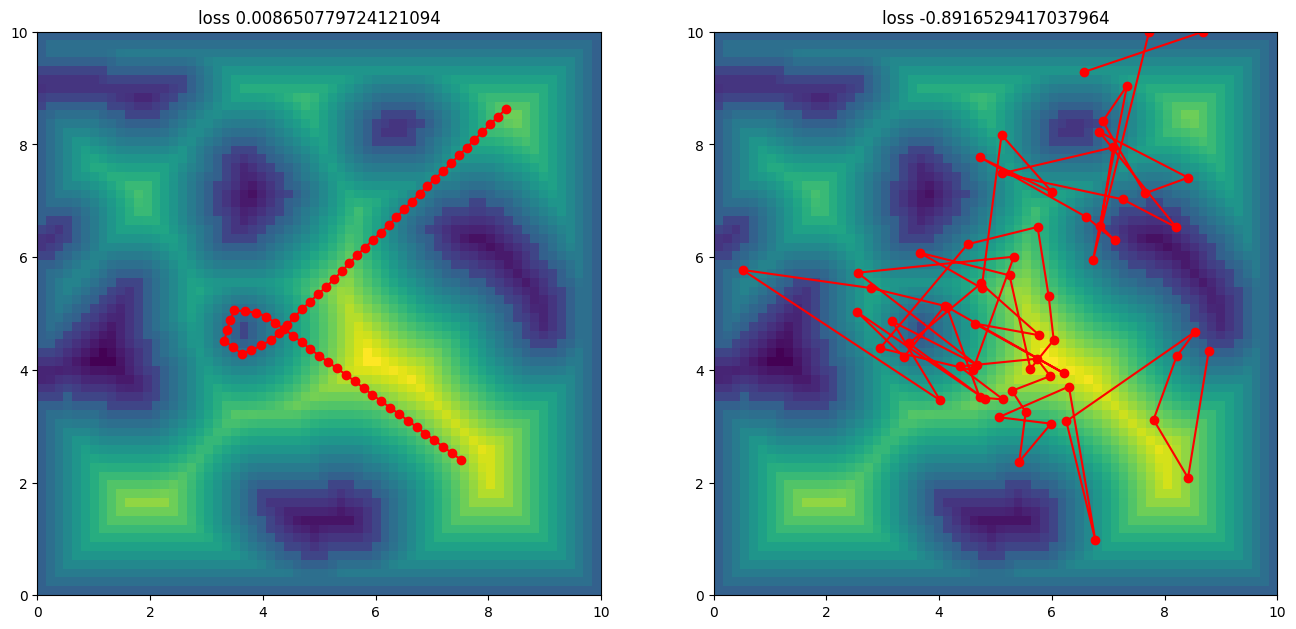

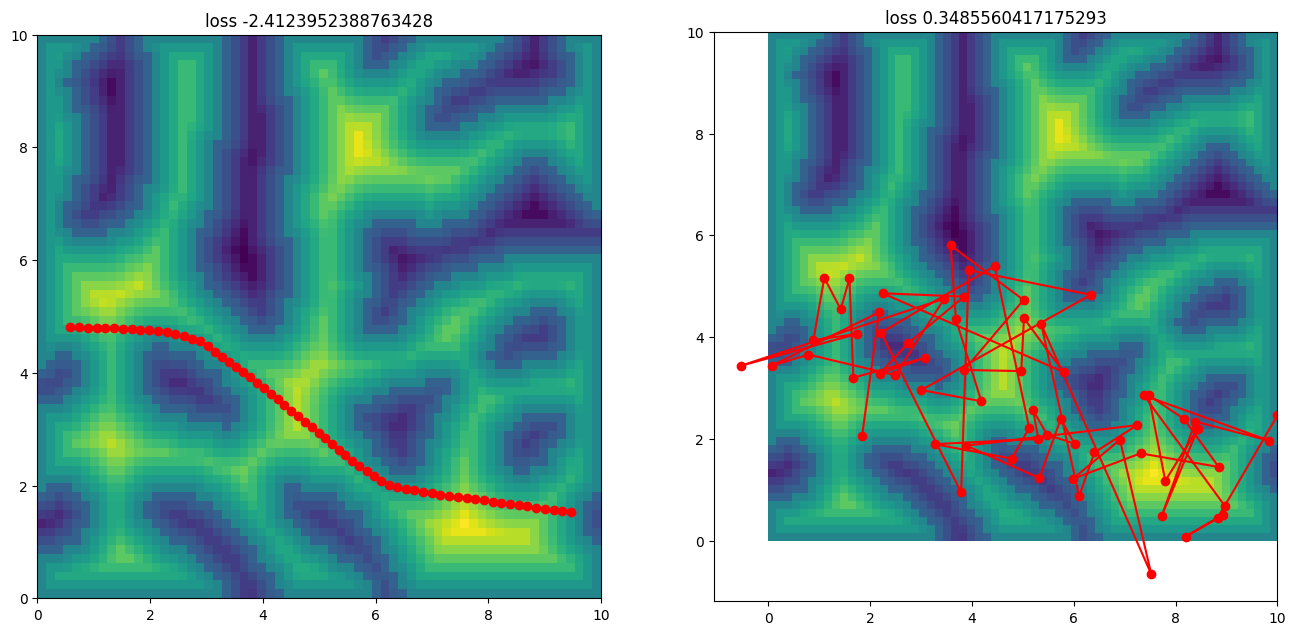

In [191]:
NOISE_TO_ADD_ON_PATH = 0.1
# This loss punishes the model for generating paths that collide with obstacles. 
for i in range(3):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = obstacle_avoidance_loss_fn(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * NOISE_TO_ADD_ON_PATH
    path = path + noise
    l = obstacle_avoidance_loss_fn(path, dimg)
    dimg = sample['world_distance_field_img']
    path_vis = obstacle_avoidance_loss_fn.normalizer.denormalize(path).cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')


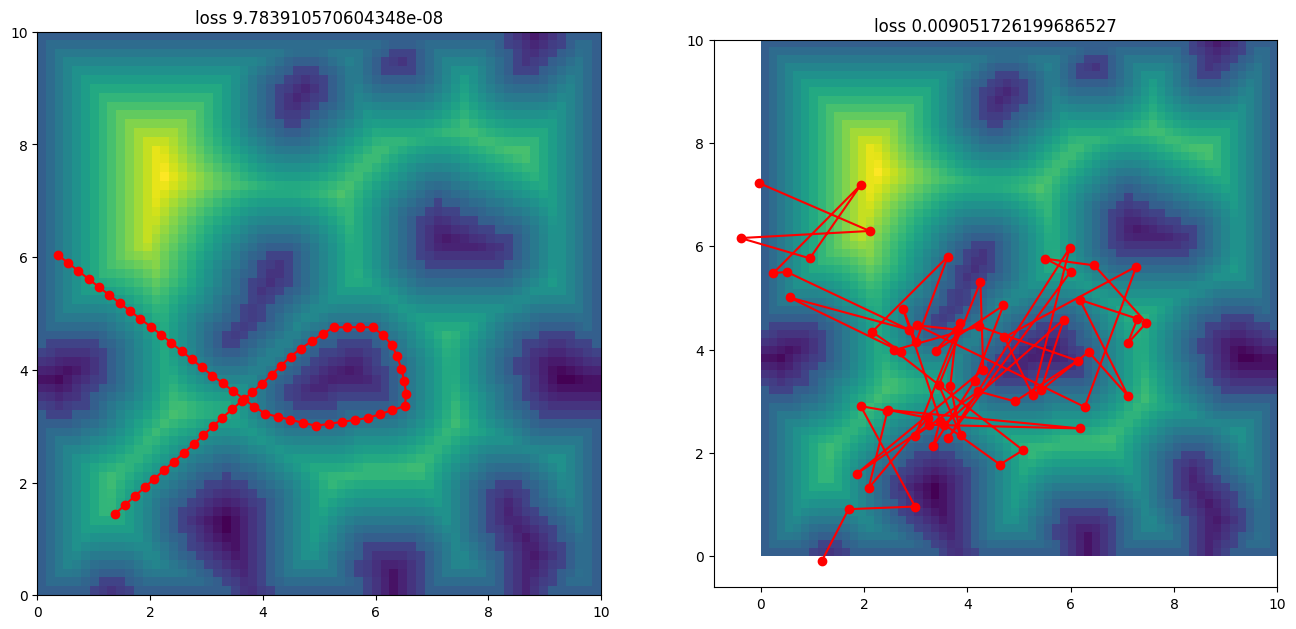

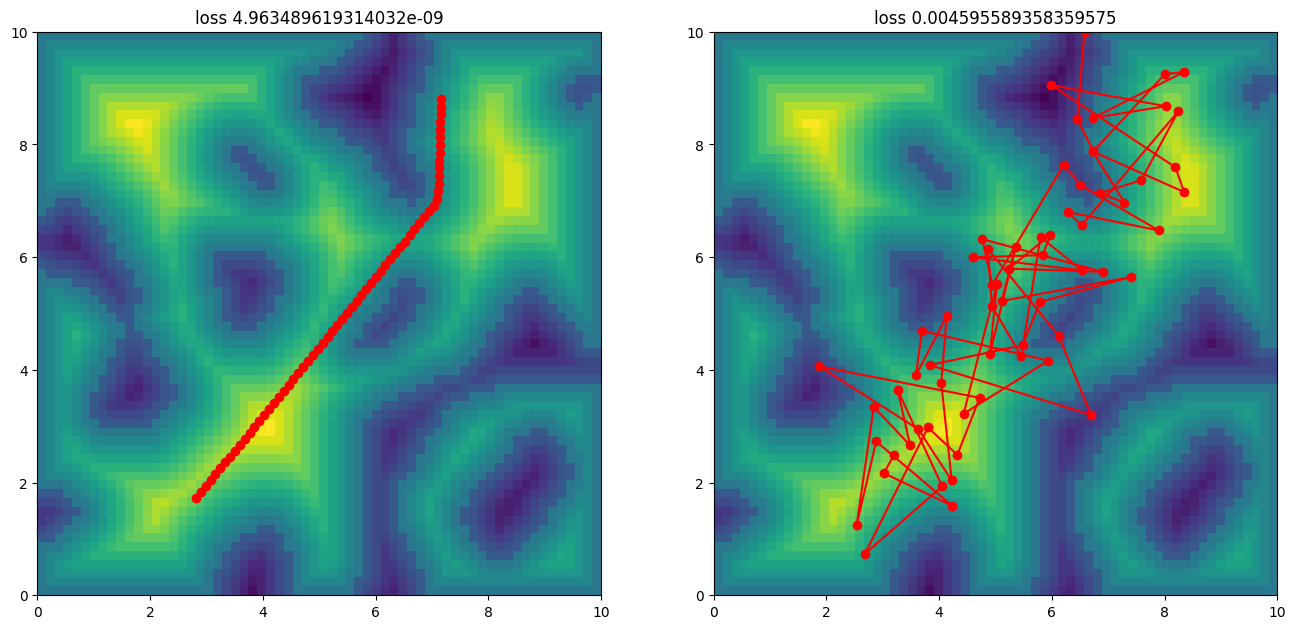

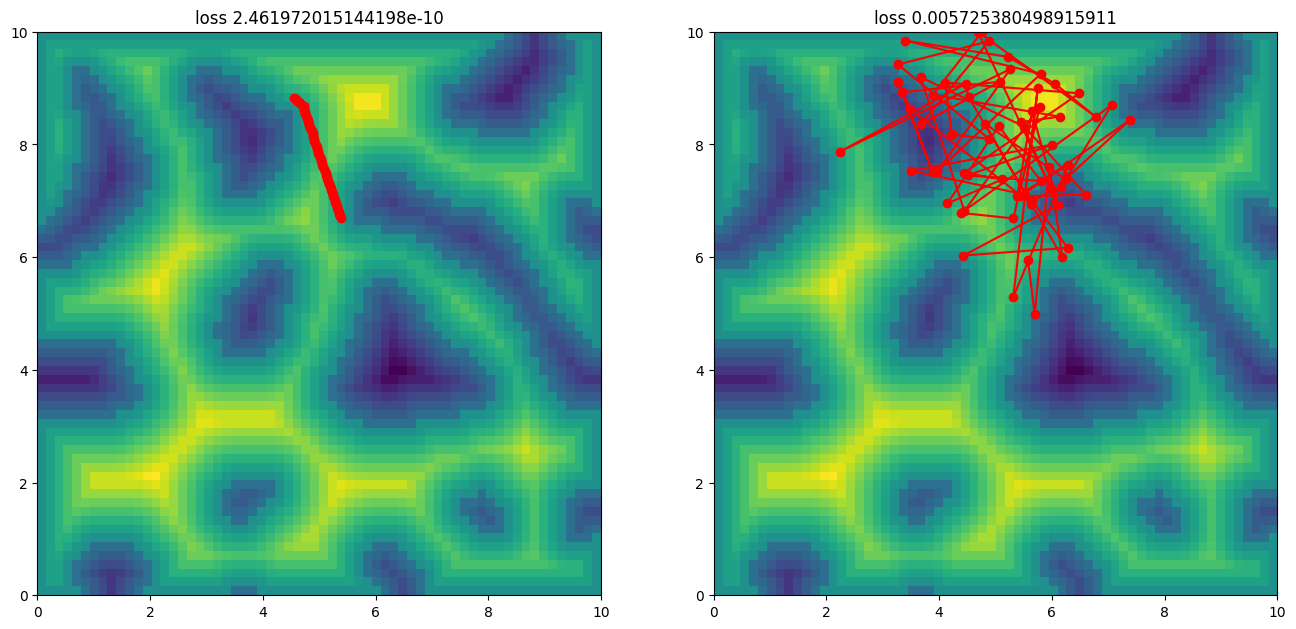

In [192]:
NOISE_TO_ADD_ON_PATH = 0.1
# This loss punishes the model for generating paths that collide with obstacles. 
for i in range(3):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = graph_based_consistency_loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * NOISE_TO_ADD_ON_PATH
    path = path + noise
    l = graph_based_consistency_loss_fn(path)
    dimg = sample['world_distance_field_img']
    path_vis = obstacle_avoidance_loss_fn.normalizer.denormalize(path).cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

# Archtechture

### encoder

In [193]:
from model import WorldIndexEmbeder, FlattenEmbeder, VAEXperiment

In [194]:
# Import pretrained vae model
model_experiment = VAEXperiment.load_from_checkpoint(r'/home/karim.samir.lotfy/tum-adlr-ss24-09/lightning_logs/version_10/checkpoints/epoch=227-step=256500.ckpt')
model_experiment.freeze()
vae_model = model_experiment.model
vae_model.to(device)
vae_model.encoder.to(device)

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (1): Sequential(
    (0): Conv2d(4, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(

In [195]:
from model import Encoder
class wrapper_encoder(Encoder):
    def __init__(self, vae_model):
        super(wrapper_encoder, self).__init__()
        self.vae_model = vae_model
    def forward(self, x):
        results = self.vae_model.encode(x)
        mu, log_var = results
        z = self.vae_model.reparameterize(mu, log_var)
        return z

    def decode(self, z):
        return self.vae_model.decode(z)

In [196]:
embedding_dim = CONFIG['encoder_conditional_dim']
# Define the model
sample_input = sample['world_distance_field_img']
encoder = wrapper_encoder(vae_model)

In [197]:
sample_batch = sample_batch
dimgs = sample_batch['world_distance_field_img'].to(device)
encoding = encoder(dimgs)

In [198]:

# assert encoding.shape[1] == CONFIG['encoder_conditional_dim']
encoding.shape

torch.Size([8, 64])

### Model and diffusion

In [199]:
from model import Diffusion, TemporalUnet

In [200]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['noise_steps'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, attention=CONFIG['attention'],device=device)

2
[ models/temporal ] Channel dimensions: [(2, 64), (64, 128), (128, 256), (256, 512)]
[ models/temporal ] Embedding dimensions: env encoding 32, start_pos encoding 8, end_pos encoding 8, time encoding 16
[(2, 64), (64, 128), (128, 256), (256, 512)]


In [201]:
model.to(device);
model.device

device(type='cuda', index=0)

In [202]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['offset_path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [203]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x['offset_path'], timesteps)
assert y.shape == (batch_size, CONFIG['n_waypoints'], 2)
y.shape

torch.Size([8, 64, 2])

In [204]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
# Create timesteps that are liner
timesteps = torch.linspace(1, CONFIG['noise_steps']-1, steps=batch_size, dtype=torch.int).to(device)
x_t, noise = diffusion.noise_input(sample_batch['offset_path'],timesteps)
x_t.shape, noise.shape

(torch.Size([8, 64, 2]), torch.Size([8, 64, 2]))

In [205]:
sample_batch.keys()

dict_keys(['path', 'og_path', 'world_indx', 'world_img', 'world_distance_field_img', 'offset_path', 'straight_line_path'])

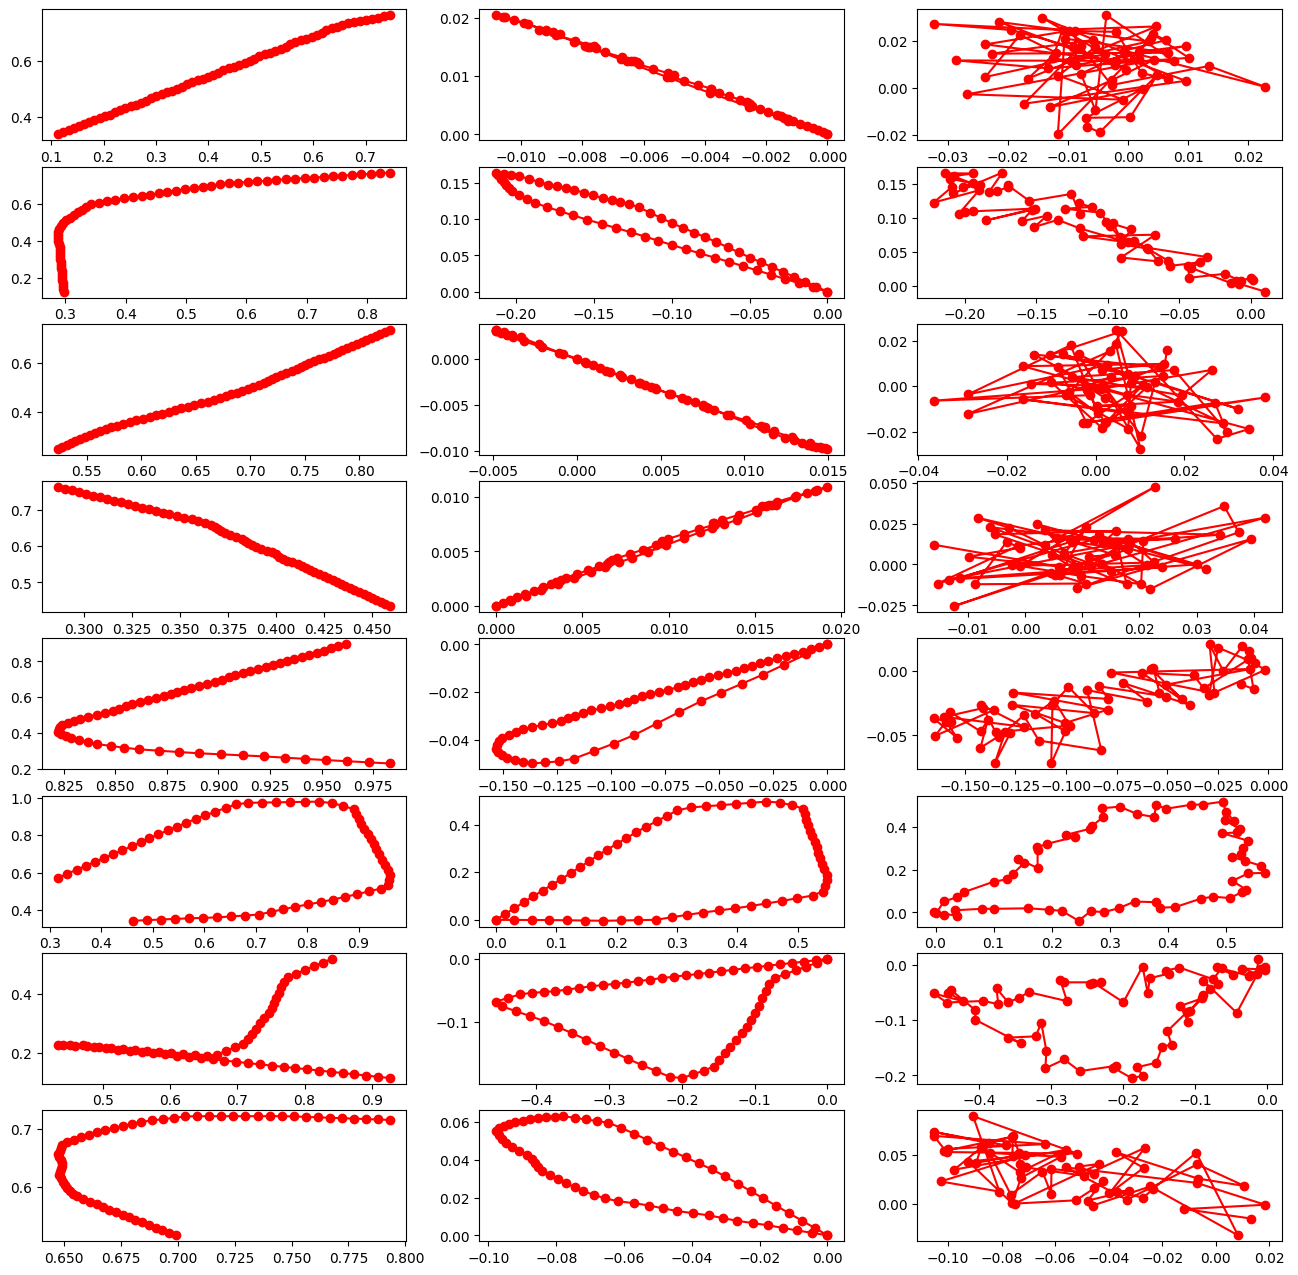

In [206]:
# PLOT INPUT VS NOISED INPUT
# create a subpolt for 2 graphs
fig, axs = plt.subplots(batch_size, 3, figsize=(16, 16))
for i in range(batch_size):
    # the 1st will be the path and its distance field + loss value 
    path = sample_batch['path'][i].cpu().detach().numpy()
    axs[i, 0].plot(path[:, 0], path[:, 1], '-o', color='red')
    # the 2nd will be the path + some noise and its distance field + loss value
    path_noised = sample_batch['offset_path'][i].cpu().detach().numpy()
    axs[i, 1].plot(path_noised[:, 0], path_noised[:, 1], '-o', color='red')
    # the 3rd will be the path + some noise and its distance field + loss value
    path_noised = x_t[i].cpu().detach().numpy()
    axs[i, 2].plot(path_noised[:, 0], path_noised[:, 1], '-o', color='red')

In [207]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch['path'][0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
# visualize_diffusion_process(x, x_t, normalizer=normalizer)
# visualize_diffusion_process(x, x_t, normalizer=None)


tensor([117,  71, 173, 107, 151], device='cuda:0')


# Training

### Set up validation and plotting function

In [208]:
# write training loop 
import torch.optim as optim
import torch.nn as nn
from utils.visualize.vae import plot_vae_reconstruciton
from utils.visualize.diffusion import plot_diffusions, plot_noise_and_predicted_noise

### Set up LoggingManager

In [209]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name=EXPERIMENT_NAME)
logging_manager.log_config(CONFIG);

INFO:LoggingManager:Configuration:
INFO:LoggingManager:representation_dim: 64
INFO:LoggingManager:dim_mults: (1, 2, 4, 8)
INFO:LoggingManager:attention: False
INFO:LoggingManager:num_heads: 4
INFO:LoggingManager:num_layers: 4
INFO:LoggingManager:use_sin_activation: True
INFO:LoggingManager:embeder_num_of_hidden_layers: 1
INFO:LoggingManager:encoder_conditional_dim: 32
INFO:LoggingManager:batch_size: 8
INFO:LoggingManager:num_epochs: 1000
INFO:LoggingManager:ema: <model.models.EMA object at 0x7fb9f25ad900>
INFO:LoggingManager:optimizer: <class 'prodigyopt.prodigy.Prodigy'>
INFO:LoggingManager:optimizer_kwargs: {'lr': 1.0, 'weight_decay': 0.01, 'safeguard_warmup': True, 'use_bias_correction': True, 'betas': (0.9, 0.99)}
INFO:LoggingManager:scheduler: <class 'torch.optim.lr_scheduler.CosineAnnealingLR'>
INFO:LoggingManager:scheduler_kwargs: {'T_max': 10}
INFO:LoggingManager:loss_weights: {'MSE': 0.3, 'ObstacleFreePathLoss': 0.5, 'GraphBasedConsistencyLoss': 0.2}
INFO:LoggingManager:noise_

Logging to logs/100 world 1000 path overfit offset-encoding end2end encoder trianing/20h-07m-05-06-2024/logs.log


In [210]:
# log the model and input sample 
input_tensor = sample_batch['path']
cond = sample_batch['world_distance_field_img']
# logging_manager.tb_log_graph(model)

# Train 

In [211]:
START_FROM_CHECKPOINT = False
Checkpoint_file = r"logs/big-model+new obstacle loss/20h-39m-21-05-2024/model-epoch_4-loss_0.100-time_21h-22m-21-05-2024"

In [212]:
# train the model

import random


optimizer = CONFIG['optimizer'](model.parameters(), **CONFIG['optimizer_kwargs'])
scheduler = CONFIG['scheduler'](optimizer, **CONFIG['scheduler_kwargs'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)
epoch = 0
# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')
    print(f'Restarting from epoch {epoch} with loss {loss}')


Using decoupled weight decay


In [213]:

for epoch in range(epoch, CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader), leave=True)
    running_loss = 0.0
    # iterate over the dataset
    for i, batch_and_info in enumerate(pbar):
        batch, batch_world_indx, batch_world_img, batch_world_distance_field_img, batch_relative, batch_straight_line = batch_and_info['path'], batch_and_info['world_indx'], batch_and_info['world_img'], batch_and_info['world_distance_field_img'], batch_and_info['offset_path'], batch_and_info['straight_line_path']
        
        
        # Training step
        model.train()
        optimizer.zero_grad()
        x = batch_relative.to(device)
        cond = batch_world_distance_field_img.to(device)
        start_pos = x[:, 0, :]
        end_pos = x[:, -1, :]
        # if random.random() < 0.1: # in 10% of the time. sample unconditional. This is to use CFG
        #     cond = None
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen, cond, start_pos, end_pos)
        # pred_offset_path = model(x_t, timesteps_choosen, cond, start_pos, end_pos)
        pred_offset_path = x + pred_noise
        pred_path = batch_straight_line + pred_offset_path
            
        # Loss 
        loss_noise_prediction =nn.SmoothL1Loss()(noise, pred_noise)
        # loss_noise_prediction = nn.SmoothL1Loss()(pred_offset_path, x)
        loss_obstacle_avoidance =obstacle_avoidance_loss_fn(pred_path, cond)
        loss_graph_based_consistency =graph_based_consistency_loss_fn(pred_path)
        loss = CONFIG['loss_weights']['MSE']*loss_noise_prediction + CONFIG['loss_weights']['ObstacleFreePathLoss']*loss_obstacle_avoidance +  CONFIG['loss_weights']['GraphBasedConsistencyLoss'] * loss_graph_based_consistency
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())
        logging_manager.tb_scalar('Loss/MSE', loss_noise_prediction.item())
        logging_manager.tb_scalar('Loss/ObstacleAvoidance', loss_obstacle_avoidance.item())
        logging_manager.tb_scalar('Loss/GraphBasedConsistency', loss_graph_based_consistency.item())
        pbar.set_postfix({'loss': loss.item()})
    
        if i % 100 == 0:

            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            ema_model.eval()
            pred_noise_ema = ema_model(x_t, timesteps_choosen)
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise')
            
            # Log optimizer parameters and scheduler parameters
            logging_manager.tb_scalar('optimizer/learning_rate', optimizer.param_groups[0]['lr'])
            logging_manager.tb_scalar('optimizer/d', optimizer.param_groups[0]['d'])
            logging_manager.tb_scalar('optimizer/scheduler-lr', scheduler.get_lr()[0])
            
            # plot histogram of pred noise and noise 
            logging_manager.tb_log_histogram(noise, 'dist/noise')    
            logging_manager.tb_log_histogram(pred_noise, 'dist/pred_noise')
        
            
            # plot reconstruction of encoder 
            sample = cond
            # sample = sample.to(autoencoder.curr_device)
            recon,input_img, mu, var = model.encoder.vae_model.forward(sample)
            plot = plot_vae_reconstruciton(sample, recon)
            logging_manager.tb_log_figure(plot, 'vae_reconstruction')

            

            
    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    print(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()




    if epoch% 2 == 0:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

        if epoch > 1:
            # unfreeze the encoder
            model.encoder.requires_grad_(True)
        # # sample model
        # sample from paths 
        n = min(8, len(batch))
        paths = batch_relative[:n]
        cond = batch_world_distance_field_img[:n]
        true_paths = paths + batch_straight_line[:n]
        samples_offset , intermediates_offset = diffusion.sample_from_paths(model, n=n, paths=paths, cond=cond, normalizer=CONFIG['normalizer'])
        # intermediates.shape = (diffusion_steps_saved, batch, n_waypoints, 2)
        # make offset paths into abosolute paths in intermediates, by adding straightline now the offset is the path
        intermediates = batch_straight_line[:n].detach().cpu().numpy() + intermediates_offset
        samples = batch_straight_line[:n].detach().cpu().numpy() + samples_offset
        plot = plot_diffusions(intermediates, world_imgs=batch_world_img, normalizer=CONFIG['normalizer'], true_paths=true_paths);
        logging_manager.tb_log_figure(plot, 'diffusion_samples')
        # samples, intermediates = diffusion.sample(ema_model,5, cfg_scale=CONFIG['cfg_scale'])
        # plot = plot_diffusions(intermediates, normalizer=CONFIG['normalizer'])
        # logging_manager.tb_log_figure(plot, 'diffusion_samples_ema_cfg', step=epoch)
        for k in range(1):
            
            last_index_for_waypoints = CONFIG['n_waypoints'] - 1
            constraints = {
                0: torch.tensor([0, 0], device=device),
                last_index_for_waypoints: torch.tensor([9, 9],device=device),
            }
            n=CONFIG['batch_size']
            cond = batch_world_distance_field_img.to(device)
            world_imgs = batch_world_img
            # logging_manager.log_message(f'Generating samples from edge to edge with worlds {batch_world_indx}')
            # samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])
            # plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            # logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch);
            # sample ema model with cfg
            # samples, intermediates = diffusion.sample_with_constraints(ema_model, n=n, constraints=constraints, cond=cond, normalizer=CONFIG['normalizer'], cfg_scale=CONFIG['cfg_scale'])
            # plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            # logging_manager.tb_log_figure(plot, f'samples edge to edge World {k} ema+cfg', step=epoch);
            
        # log model embedding space
        # features = model.get_last_embedding()
        # metadata = batch_world_indx
        # metadata should be a list of strings
        # metadata = [f'world {str(i)}' for i in metadata]
        # images = batch_world_img # batch * 64 * 64
        # images = images.unsqueeze(1) # turn to batch * C * H * W
        # logging_manager.tb_log_embedding_space(features, metadata, images)
        
        # # log model weights
        # last_layer_weights = model.final_conv[-1].weight
        # logging_manager.tb_log_histogram(last_layer_weights, 'final layer wieghts')
        # # log model embedding space weights
        # embedding_weights = model.encoder.embedding[-2].weight
        # logging_manager.tb_log_histogram(embedding_weights, 'embedding layer wieghts')
 
        
        
print('Finished Training')    

  0%|          | 0/1375 [00:00<?, ?it/s, loss=0.156]

  2%|▏         | 24/1375 [00:08<07:59,  2.82it/s, loss=0.219] 


KeyboardInterrupt: 

# Sample Model

In [214]:
Checkpoint_file = "/home/karim.samir.lotfy/tum-adlr-ss24-09/logs/100 world 1000 path overfit offset-encoding end2end encoder trianing/19h-09m-01-06-2024/model-epoch_18-loss_0.092-time_21h-09m-01-06-2024"
model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)


INFO:LoggingManager:Checkpoint loaded from /home/karim.samir.lotfy/tum-adlr-ss24-09/logs/100 world 1000 path overfit offset-encoding end2end encoder trianing/19h-09m-01-06-2024/model-epoch_18-loss_0.092-time_21h-09m-01-06-2024


In [215]:
# sample model with custom constraints
# get random world 
dataset_sample = dataset.get_samples(1)[0]

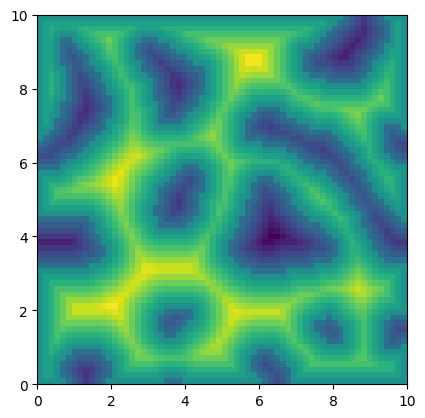

In [216]:
cond = dataset_sample['world_distance_field_img'].unsqueeze(0).to(device)
# show cond
plt.imshow(cond[0].cpu().detach().numpy().T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')

In [237]:
constraints = {
    32: torch.tensor([3.0, 3.0], device=device, dtype=torch.float32),
}

In [238]:
n = min(8, len(batch))
paths = batch_relative[:n]
cond = batch_world_distance_field_img[:n]
true_paths = paths + batch_straight_line[:n]
samples_offset , intermediates_offset = diffusion.sample_from_paths_with_constraints(model, n=n, paths=paths, constraints=constraints,  cond=cond, normalizer=CONFIG['normalizer'])

255it [00:05, 47.90it/s]


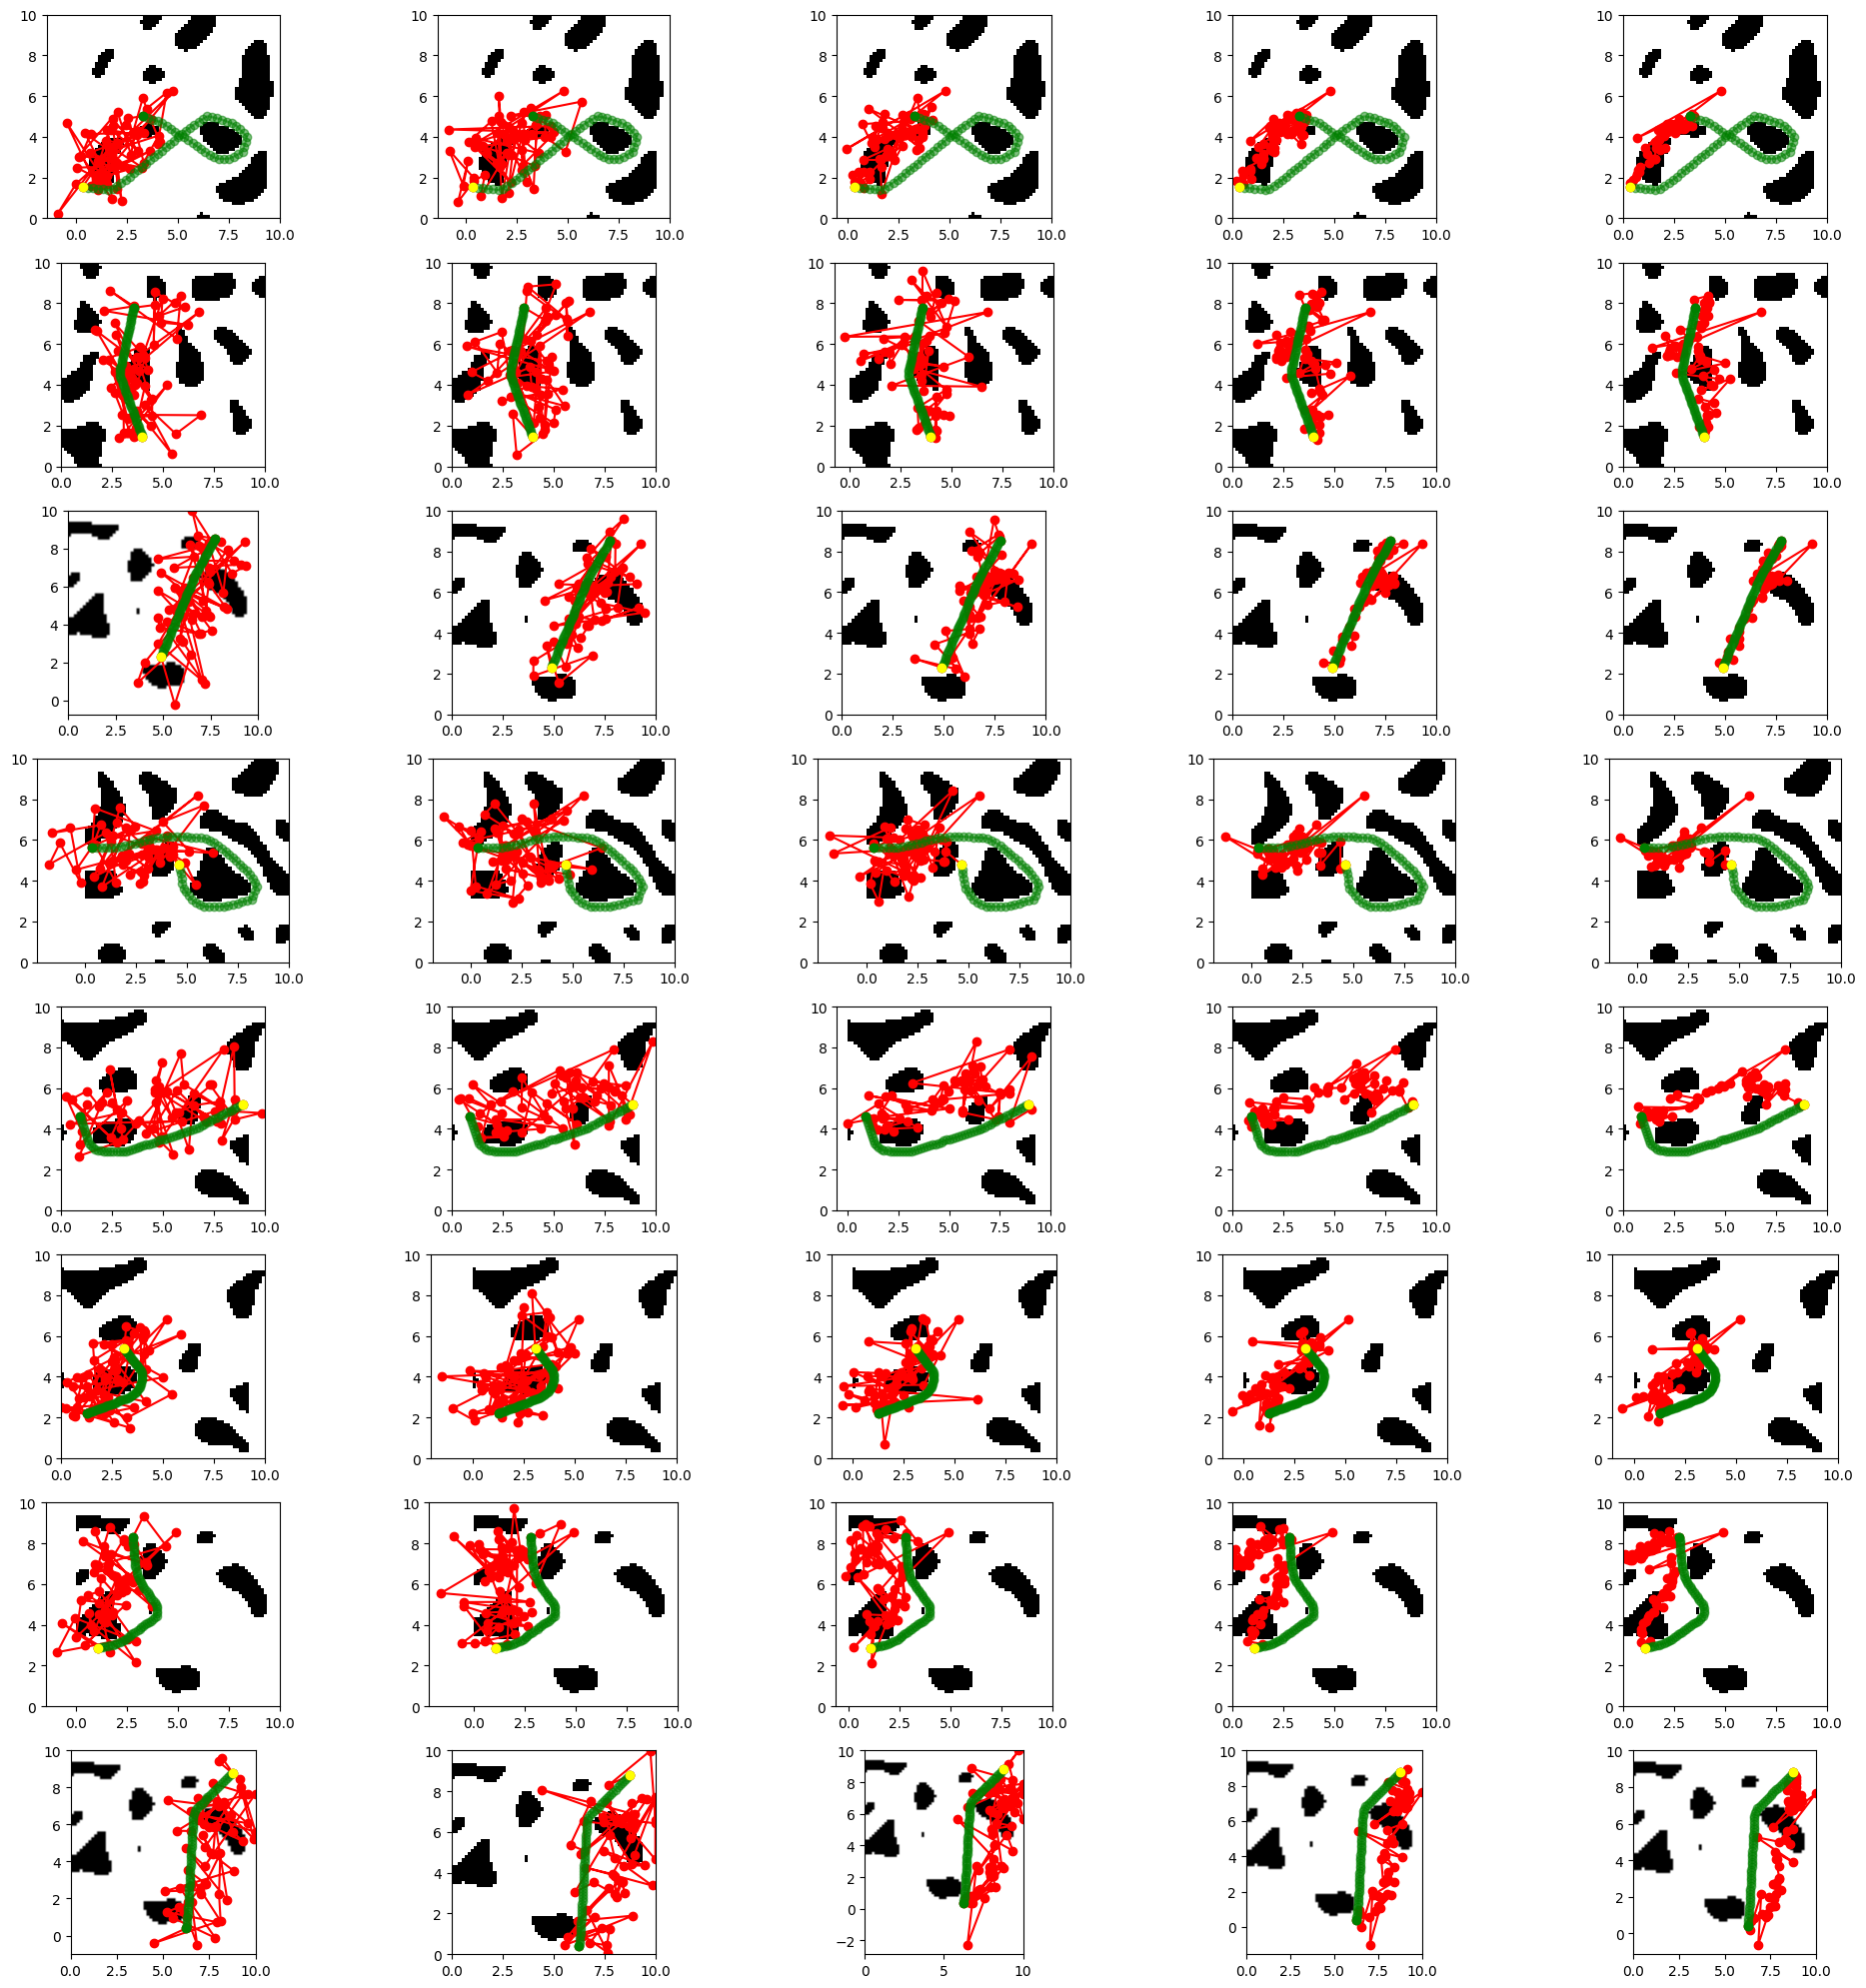

In [239]:
intermediates = batch_straight_line[:n].detach().cpu().numpy() + intermediates_offset
samples = batch_straight_line[:n].detach().cpu().numpy() + samples_offset
plot = plot_diffusions(intermediates, world_imgs=batch_world_img, normalizer=CONFIG['normalizer'], true_paths=true_paths);
plt.show()

In [227]:
samples[0][31:34]

array([[ 0.1384759 ,  0.48756036],
       [ 0.6796228 ,  0.8247115 ],
       [-0.03735702,  0.12627636]], dtype=float32)